In [5]:
import pickle
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath(".."))

from Knowledge_Alignment_Loss import KAL

In [2]:
# Simulation Data
with open("./simulation_data.pickle","rb") as fr:
    data = pickle.load(fr)

X = torch.tensor(data['X'], dtype=torch.float32)
y = torch.tensor(data['y'], dtype=torch.float32)

# K-fold setting
with open("./5fold_setting.pickle","rb") as fr:
    fold_setting = pickle.load(fr)

# Knowledge Guided Features
idx = np.array([0,1,2])

In [3]:
# BaseLine model (MLP)
class Baseline_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, input_dim)
        self.fc2 = nn.Linear(input_dim, math.ceil(input_dim**0.5))
        self.fc3 = nn.Linear(math.ceil(input_dim**0.5), math.ceil((input_dim**0.5)**0.5))
        self.out = nn.Linear(math.ceil((input_dim**0.5)**0.5), 1)

    def forward(self, x, return_hidden=False):
        z1 = self.fc1(x)
        h1 = torch.relu(z1)

        h2 = torch.relu(self.fc2(h1))
        h3 = torch.relu(self.fc3(h2))

        out = self.out(h3).squeeze(-1)

        if return_hidden:
            return out, h1
        return out

# Feature importance score
def gradient_feature_importance(model, X):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    X = X.to(device)
    X.requires_grad_(True)

    out = model(X).squeeze(-1)
    out.sum().backward()
    grads = X.grad.abs()
    importance = grads

    return importance.detach().cpu()

In [4]:
bs = 32
lr = 1e-2
patience = 100
epochs = 100000
criterion_y = nn.MSELoss()

lambda_per = {}
for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]:
    k_per = {}
    for k in range(5):
        train_x = X[fold_setting[k]['train']]
        train_y = y[fold_setting[k]['train']]
        
        val_x = X[fold_setting[k]['val']]
        val_y = y[fold_setting[k]['val']]
        
        test_x = X[fold_setting[k]['test']]
        test_y = y[fold_setting[k]['test']]
        N, D = train_x.shape
        
        ds = TensorDataset(train_x, train_y)
        loader = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=True)
        
        device = "cuda" if torch.cuda.is_available() else "cpu"
        model = Baseline_MLP(D).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        model.train()
        
        best_val_loss = float("inf")
        best_val_total_loss = float("inf")
        best_state = None
        patience_counter = 0
        
        for epoch in range(epochs):
            for xb, yb in loader:
                xb = xb.to(device)
                yb = yb.to(device)
        
                optimizer.zero_grad()
        
                # Task loss
                preds, h1 = model(xb, return_hidden=True)
                loss = criterion_y(preds, yb)
                
                # Knowledge Alignment Loss
                loss_KAL = KAL(xb[:,idx], h1)
                # Total loss
                total_loss = loss + lambda_KAL * loss_KAL
        
                total_loss.backward()
                optimizer.step()
        
            vs = val_x.to(device)
            vy = val_y.to(device)
        
            # Task loss
            vout, vh1 = model(vs, return_hidden=True)
            vloss = criterion_y(vout, vy)
        
            # Knowledge Alignment Loss
            vloss_KAL = KAL(vs[:,idx], vh1)
            # Total loss
            vtotal_loss = vloss + lambda_KAL * vloss_KAL
        
            if vloss < best_val_loss:
                best_val_loss = vloss
                best_state = model.state_dict()
            if vtotal_loss < best_val_total_loss:
                best_val_total_loss = vtotal_loss
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                break    
        
        model.load_state_dict(best_state)
        model.eval()
        
        per_list = {}
        for x, temp_y, target in zip([train_x, val_x, test_x],
                                   [train_y, val_y, test_y],
                                   ['train', 'val', 'test']):
            with torch.no_grad():
                x_device = x.to(device)
                y_device = temp_y.to(device) 
                estimate = model(x_device)
            
            temp = criterion_y(estimate, y_device)
            
            per_list[target] = temp.item()
            
        FIMP = gradient_feature_importance(model, X.detach()).numpy()
        k_per[k] = {'MSE': per_list, 'Feature_importance': FIMP}
    print('lambda_KAL ({0}):'.format(lambda_KAL), round(sum([k_per[ii]['MSE']['test'] for ii in range(5)])/5, 4))
    lambda_per[lambda_KAL] = k_per

lambda_KAL (0): 0.9867
lambda_KAL (0.001): 0.7436
lambda_KAL (0.01): 0.6455
lambda_KAL (0.1): 0.5272
lambda_KAL (1.0): 0.5813
lambda_KAL (10.0): 0.6725


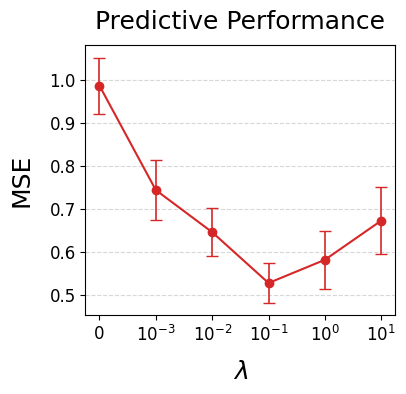

In [8]:
MSEs = np.array([[lambda_per[lambda_KAL][k]['MSE']['test'] for k in range(5)] for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]])
MSE  = [i.mean() for i in MSEs]
MSE_err  = [i.std()/(5**0.5) for i in MSEs]

plt.figure(figsize=(4, 3.5))
plt.errorbar(
    range(6), MSE, yerr=MSE_err,
    marker='o', c='#d62728',
    capsize=4, elinewidth=1.2,
    label='Knowledge-based features'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylabel('MSE', fontsize = 18, labelpad = 11)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.xlabel('$\lambda$', fontsize = 18, labelpad = 11)
plt.title('Predictive Performance', size = 18, pad = 12)
plt.show()

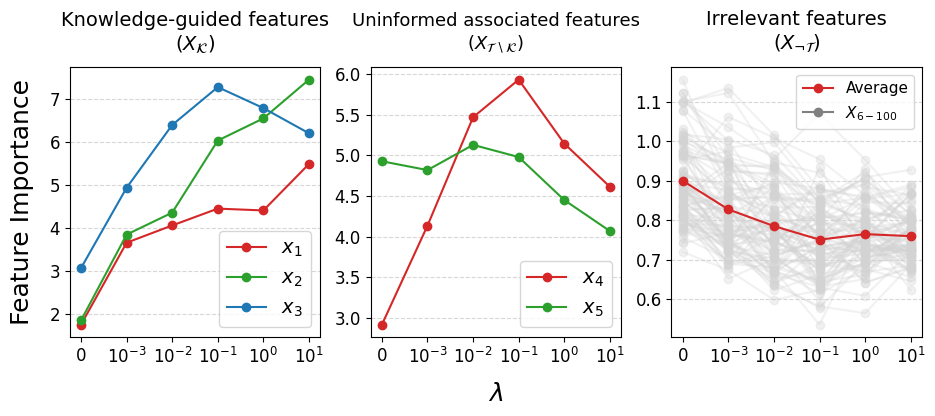

In [77]:
lambda_FI = {}
for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]:
    K_FI = []
    for k in range(5):
        raw_FI = lambda_per[lambda_KAL][k]['Feature_importance'].mean(axis = 0)
        raw_FI = raw_FI/raw_FI.mean()
        K_FI.append(raw_FI.tolist())
    lambda_FI[lambda_KAL] = np.array(K_FI)

plt.figure(figsize=(11, 3.5))
colors = ['#d62728', '#2ca02c', '#1f77b4']

plt.subplot(1,3,1)
for ii, x_idx in enumerate([0,1,2]):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, marker='o', c=colors[ii], label='$x_{'+str(x_idx+1)+'}$')

plt.legend(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Knowledge-guided features\n'+r'($X_{\mathcal{K}}$)', size = 14, pad = 13)
plt.ylabel('Feature Importance', fontsize = 18, labelpad = 11)

plt.subplot(1,3,2)
for ii, x_idx in enumerate([3,4]):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, marker='o', c=colors[ii], label='$x_{'+str(x_idx+1)+'}$')

plt.legend(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Uninformed associated features\n'+r'($X_{\mathcal{T} \setminus \mathcal{K}}$)', size = 13, pad = 13)
plt.xlabel('$\lambda$', fontsize = 18, labelpad = 11)

plt.subplot(1,3,3)
for ii, x_idx in enumerate(list(range(5,100))):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, c = 'lightgray', marker = 'o', alpha = 0.3)

KI_mean = [lambda_FI[lambda_KAL][:,5:].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
plt.plot(KI_mean, marker='o', c='#d62728', label = 'Average')
plt.plot([], [], marker='o', color='gray', label='$X_{6-100}$')
plt.legend(fontsize = 11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Irrelevant features\n'+r'($X_{\neg\mathcal{T}}$)', size = 14, pad = 13)

plt.show()